In [1]:
# CELL 1: Load Data
from data_setup import load_all

ctx = load_all(data_dir="ml-1m")

[download] 'ml-1m/' already exists — skipping.
[load] ratings: 1,000,209  movies: 3,883  users: 6,040
[mappings] users: 6,040  movies: 3,706  genres: 18
[split] train: 800,167  test: 200,042  R_train nnz: 800,167
[svd] Computing SVD (k=50) ...
[svd] U_embed: (6040, 50)  M_embed: (3706, 50)
[xgb] Training XGBoost simulator ...
[xgb] Accuracy: 0.673  AUC-ROC: 0.734
[save] XGBoost → outputs/simulators/xgb_simulator.json

[load_all] Pipeline complete.


Ratings      : 1,000,209
Users        : 6,040
Movies       : 3,706
Genres       : 18
Sparsity     : 95.53%
Avg rat/user : 165.6
Avg rat/movie: 269.9
Like rate    : 57.52%


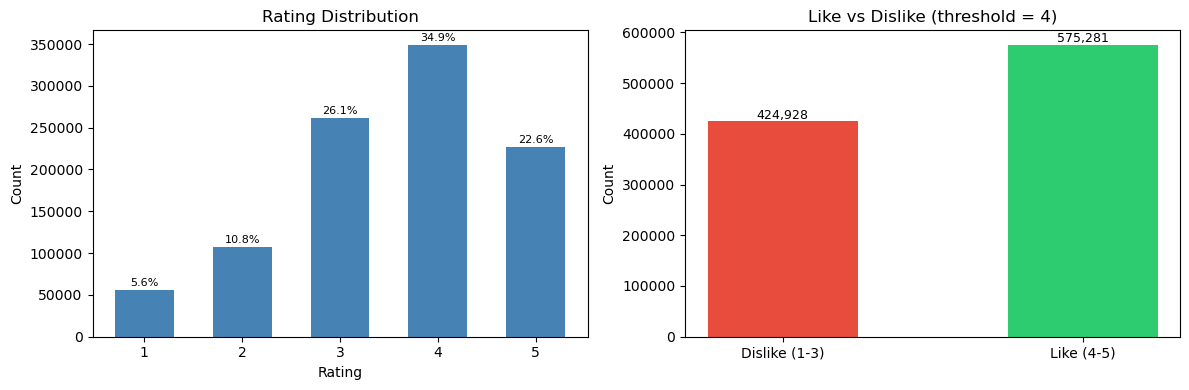

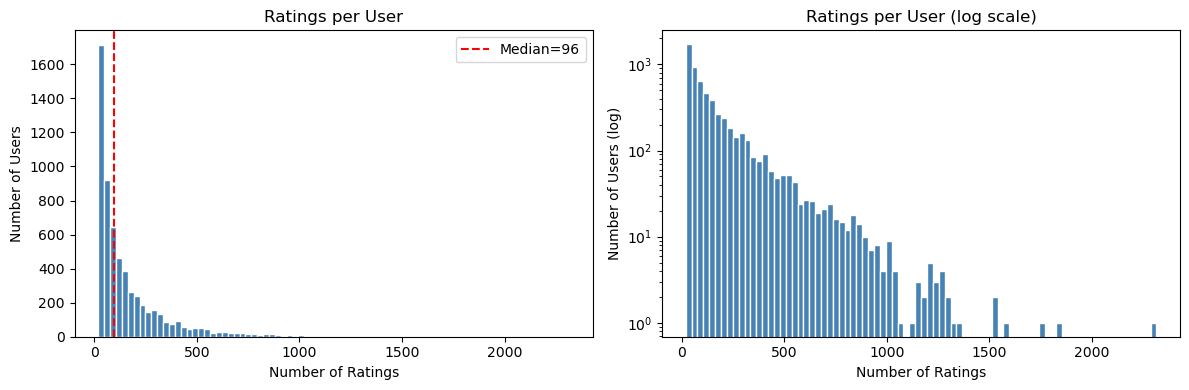

  P10: 27
  P25: 44
  P50: 96
  P75: 208
  P90: 400
  P95: 556
  P99: 907


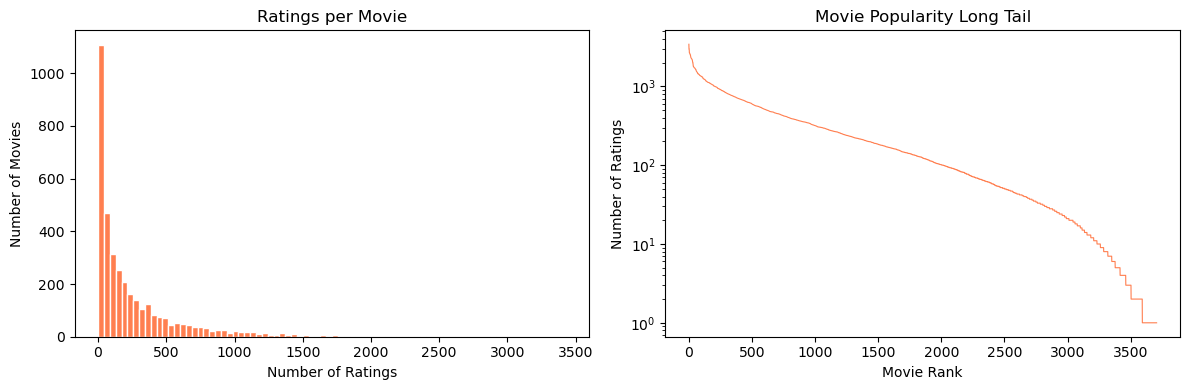

Movies with ≤10 ratings : 473
Movies with ≤50 ratings : 1207

Top 10 most rated:
  American Beauty (1999)                        3,428
  Star Wars: Episode IV - A New Hope (1977)     2,991
  Star Wars: Episode V - The Empire Strikes Back (1980) 2,990
  Star Wars: Episode VI - Return of the Jedi (1983) 2,883
  Jurassic Park (1993)                          2,672
  Saving Private Ryan (1998)                    2,653
  Terminator 2: Judgment Day (1991)             2,649
  Matrix, The (1999)                            2,590
  Back to the Future (1985)                     2,583
  Silence of the Lambs, The (1991)              2,578


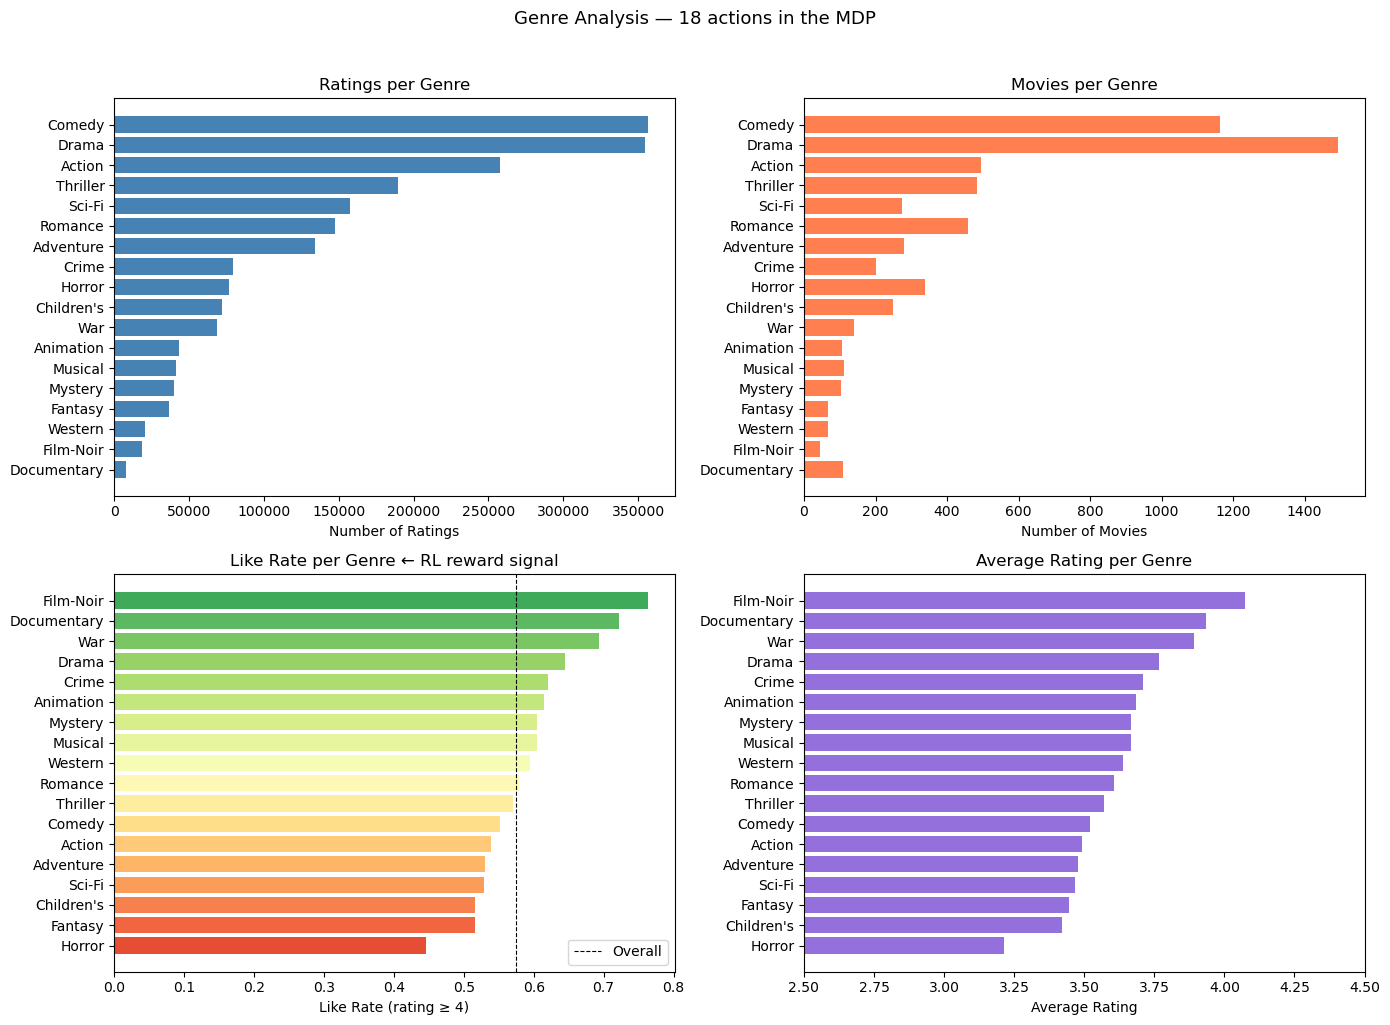

Saved → eda/genre_stats.csv
             n_ratings  n_movies  avg_rating  like_rate
genre                                                  
Comedy          356580      1163       3.522      0.552
Drama           354529      1493       3.766      0.644
Action          257457       495       3.491      0.539
Thriller        189680       485       3.570      0.571
Sci-Fi          157294       274       3.467      0.529
Romance         147523       459       3.607      0.580
Adventure       133953       281       3.477      0.530
Crime            79541       201       3.709      0.620
Horror           76386       339       3.215      0.446
Children's       72186       250       3.422      0.516
War              68527       141       3.893      0.694
Animation        43293       105       3.685      0.615
Musical          41533       113       3.666      0.605
Mystery          40178       104       3.668      0.605
Fantasy          36301        68       3.447      0.516
Western          206

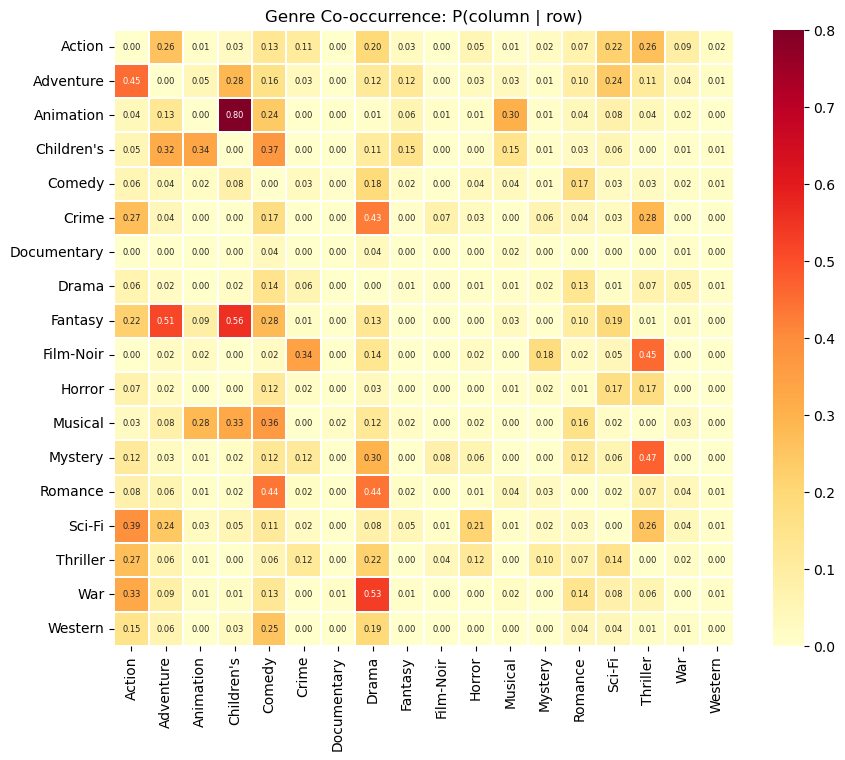

Saved → eda/genre_cooccurrence.npy
Saved → eda/genre_order.csv
Average genres per movie: 1.67


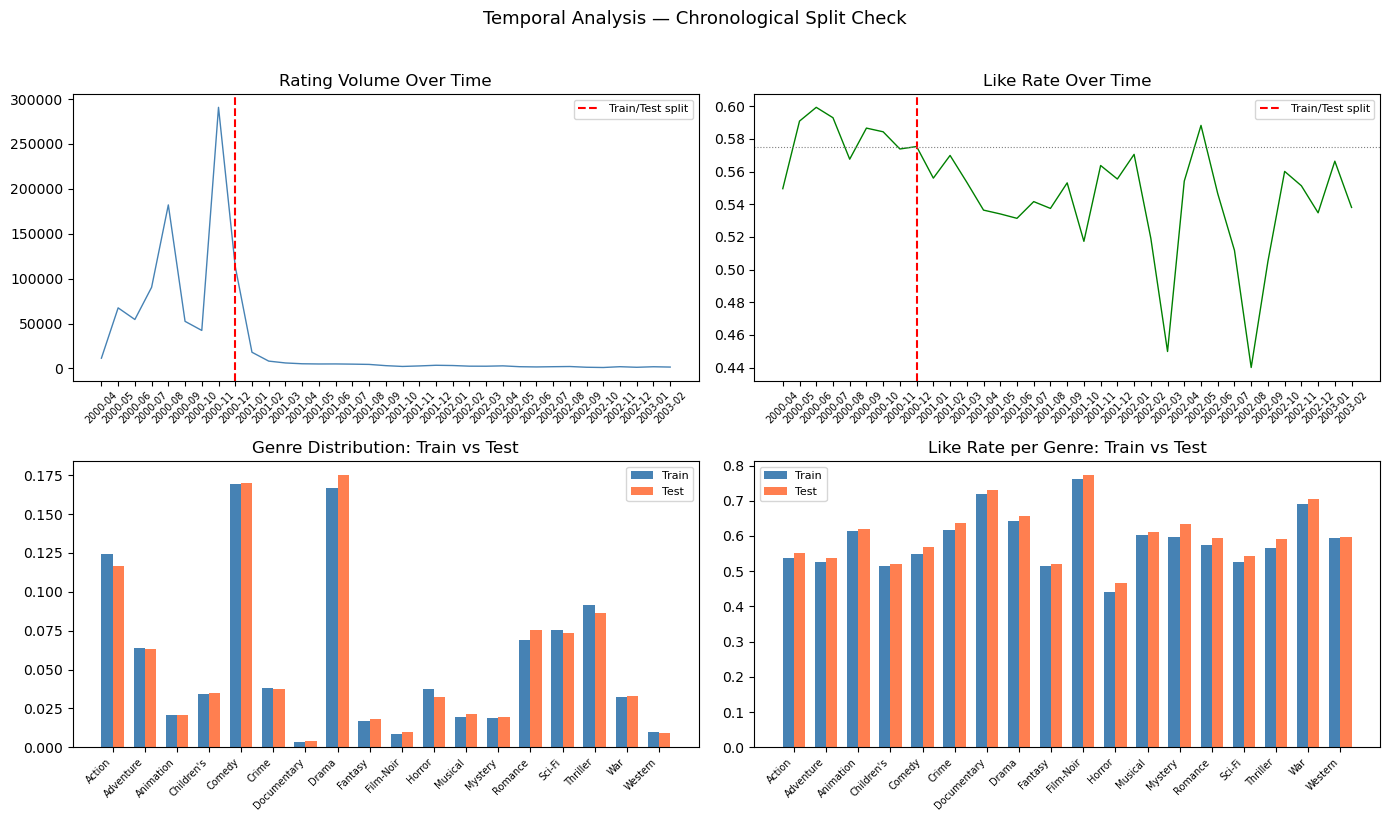

Genre distribution shift (L1): 0.0427
Top shifted genres:
  Drama          : Δ=0.0083
  Action         : Δ=0.0075
  Romance        : Δ=0.0064
  Horror         : Δ=0.0053
  Thriller       : Δ=0.0052


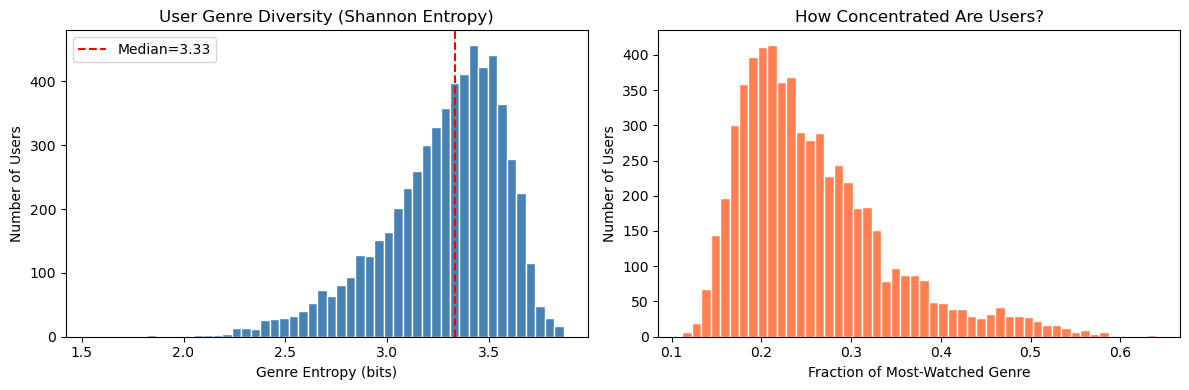

Saved → eda/user_genre_diversity.csv
Entropy  — Mean: 3.27  Median: 3.33  Max possible: 4.17
Dom frac — Mean: 25.79%  Median: 23.79%


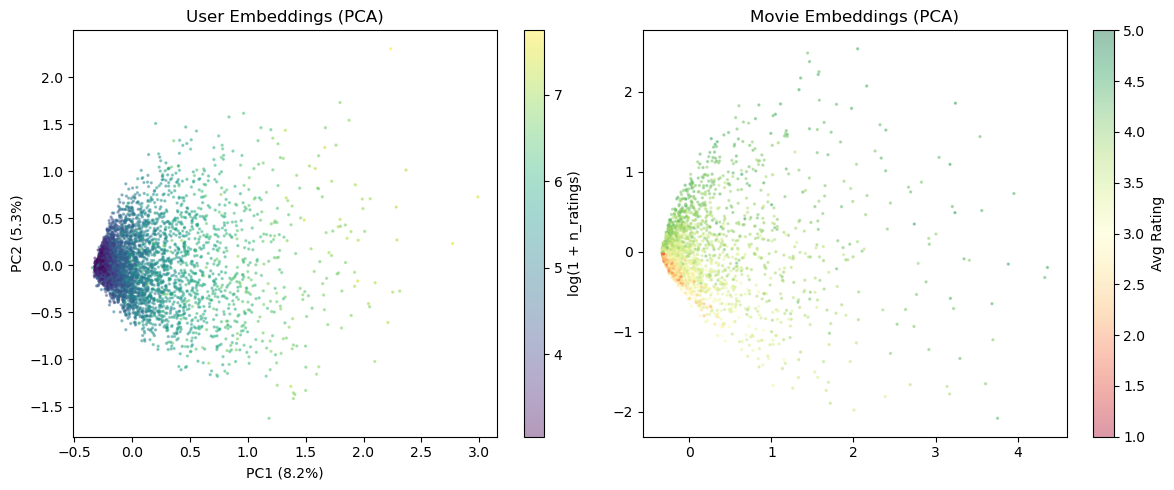

User PCA explained variance: 13.6%
All EDA outputs in 'eda/':

Plots:
  01_rating_distribution.png
  02_user_activity.png
  03_movie_popularity.png
  04_genre_analysis.png
  05_genre_cooccurrence.png
  06_temporal_analysis.png
  07_user_genre_diversity.png
  08_svd_embeddings.png
  09_policy_comparison.png

Derived features:
  genre_cooccurrence.npy
  genre_order.csv
  genre_stats.csv
  user_genre_diversity.csv


In [2]:
# CELL 2: EDA (plots + save derived features)
from eda import run_all_eda

run_all_eda(ctx)

In [3]:
# CELL 3: Unpack ctx + load EDA features
from eda import load_genre_stats, load_genre_cooccurrence, load_user_diversity
 
# Live objects for RL pipeline
U_embed           = ctx["U_embed"]
M_embed           = ctx["M_embed"]
xgb_model         = ctx["xgb_model"]
user2idx          = ctx["user2idx"]
movie2idx         = ctx["movie2idx"]
genre_to_movies   = ctx["genre_to_movies"]
movie_genres      = ctx["movie_genres"]
get_p_like        = ctx["helpers"]["get_p_like"]
get_movie_genres  = ctx["helpers"]["get_movie_genres"]
count_same_genres = ctx["helpers"]["count_same_genres"]
 
# Saved EDA features
genre_stats            = load_genre_stats()
cooccur, genre_order   = load_genre_cooccurrence()
user_div               = load_user_diversity()
 
print(f"Loaded {len(user2idx):,} users, {len(movie2idx):,} movies")
print(f"Genre stats: {genre_stats.shape}, Co-occurrence: {cooccur.shape}")

Loaded 6,040 users, 3,706 movies
Genre stats: (18, 4), Co-occurrence: (18, 18)


In [4]:
# CELL 4: Load GRU4Rec simulator
from gru4rec import train_gru4rec, make_gru4rec_p_like

gru4rec_model  = train_gru4rec(ctx, save_dir="outputs/simulators", n_epochs=50)
gru4rec_p_like = make_gru4rec_p_like(gru4rec_model, movie2idx, T=20)

# Sanity check
sample_user  = list(user2idx.keys())[0]
sample_movie = list(movie2idx.keys())[0]
p = gru4rec_p_like(sample_user, sample_movie, episode_sequence=[])
print(f"Sanity check — P(like | user={sample_user}, movie={sample_movie}): {p:.3f}")

[gru4rec] Device: cpu
[gru4rec] Building sequence datasets ...
[gru4rec] Train sequences: 232,826  Test sequences: 64,344
[gru4rec] Training (50 epochs, patience=8, dropout=0.3, wd=0.0001) ...
  Epoch  1/50  loss=0.6633  AUC=0.6323  lr=5.0e-04
  Epoch  2/50  loss=0.6426  AUC=0.6582  lr=5.0e-04
  Epoch  3/50  loss=0.6351  AUC=0.6675  lr=5.0e-04
  Epoch  4/50  loss=0.6291  AUC=0.6779  lr=5.0e-04
  Epoch  5/50  loss=0.6237  AUC=0.6872  lr=5.0e-04
  Epoch  6/50  loss=0.6176  AUC=0.6960  lr=5.0e-04
  Epoch  7/50  loss=0.6111  AUC=0.7043  lr=5.0e-04
  Epoch  8/50  loss=0.6059  AUC=0.7121  lr=5.0e-04
  Epoch  9/50  loss=0.6008  AUC=0.7165  lr=5.0e-04
  Epoch 10/50  loss=0.5965  AUC=0.7203  lr=5.0e-04
  Epoch 11/50  loss=0.5924  AUC=0.7215  lr=5.0e-04
  Epoch 12/50  loss=0.5878  AUC=0.7222  lr=5.0e-04
  Epoch 13/50  loss=0.5843  AUC=0.7223  lr=5.0e-04
  Epoch 14/50  loss=0.5813  AUC=0.7234  lr=5.0e-04
  Epoch 15/50  loss=0.5786  AUC=0.7225  lr=5.0e-04
  Epoch 16/50  loss=0.5764  AUC=0.7235  lr

In [5]:
# CELL 5: Create environment
from env import FinalMovieRecEnvV6

env = FinalMovieRecEnvV6(ctx, gru4rec_p_like=gru4rec_p_like, T=20, window=10)

# Quick manual test
obs, info = env.reset()
print(f"Env ready — state shape: {obs.shape}, T={env.T}, window={env.window}")

for i in range(3):
    action = env.action_space.sample()
    obs, reward, done, _, info = env.step(action)
    print(f"  Step {i+1}: genre={info['genre']}, p_like={info['p_like']:.3f}, reward={reward}")
print("Manual test OK")

Env ready — state shape: (68,), T=20, window=10
  Step 1: genre=Comedy, p_like=0.465, reward=0.0
  Step 2: genre=Thriller, p_like=0.304, reward=0.0
  Step 3: genre=Western, p_like=0.565, reward=1.0
Manual test OK


In [6]:
# CELL 6: Train DQN
from stable_baselines3 import DQN
from baselines import EpisodeRewardCallback

callback_dqn = EpisodeRewardCallback()

model_dqn = DQN(
    policy        = "MlpPolicy",
    env           = env,
    policy_kwargs = dict(net_arch=[128, 128]),
    learning_rate          = 3e-4,
    gamma                  = 0.99,
    buffer_size            = 30_000,
    learning_starts        = 1000,
    batch_size             = 128,
    exploration_fraction   = 0.4,
    exploration_final_eps  = 0.05,
    train_freq             = 4,
    target_update_interval = 500,
    verbose                = 0,
    device                 = "cpu",
)

print("Training DQN (120k timesteps) ...")
model_dqn.learn(total_timesteps=200_000, callback=callback_dqn, progress_bar=True)
print(f"Done — {len(callback_dqn.episode_rewards)} episodes")

Output()

Training DQN (120k timesteps) ...


Done — 10000 episodes


In [7]:
# CELL 7: Train PPO
from stable_baselines3 import PPO

callback_ppo = EpisodeRewardCallback()

model_ppo = PPO(
    policy        = "MlpPolicy",
    env           = env,
    policy_kwargs = dict(net_arch=[128, 128]),
    learning_rate = 3e-4,
    gamma         = 0.99,
    n_steps       = 2048,
    batch_size    = 128,
    n_epochs      = 10,
    verbose       = 0,
    device        = "cpu",
)

print("Training PPO (120k timesteps) ...")
model_ppo.learn(total_timesteps=200_000, callback=callback_ppo, progress_bar=True)
print(f"Done — {len(callback_ppo.episode_rewards)} episodes")

Output()

Training PPO (120k timesteps) ...


Done — 10035 episodes


[eval] Running Bernoulli evaluation (500 episodes) ...
  random    : 7.66 ± 2.41
  greedy    : 5.67 ± 2.51
  dqn       : 7.22 ± 2.95
  ppo       : 9.98 ± 2.54

FINAL COMPARISON — BERNOULLI REWARD  (T=20, n=500)
Policy                  Mean     Std
----------------------------------------
Random                 7.660 ± 2.412
Greedy-CTR             5.670 ± 2.513
DQN                    7.224 ± 2.946
PPO                    9.978 ± 2.538

DQN vs Random     : -0.436
DQN vs Greedy-CTR : +1.554  ← key metric
PPO vs Random     : +2.318
PPO vs Greedy-CTR : +4.308  ← key metric
[eval] Running expected-reward evaluation (200 episodes) ...
  random    : 7.946 ± 1.265
  greedy    : 5.683 ± 1.639
  dqn       : 6.837 ± 1.872
  ppo       : 9.909 ± 1.469

FINAL COMPARISON — EXPECTED REWARD  (T=20, n=200)
Policy                  Mean     Std
----------------------------------------
Random                 7.946 ± 1.265
Greedy-CTR             5.683 ± 1.639
DQN                    6.837 ± 1.872
PPO          

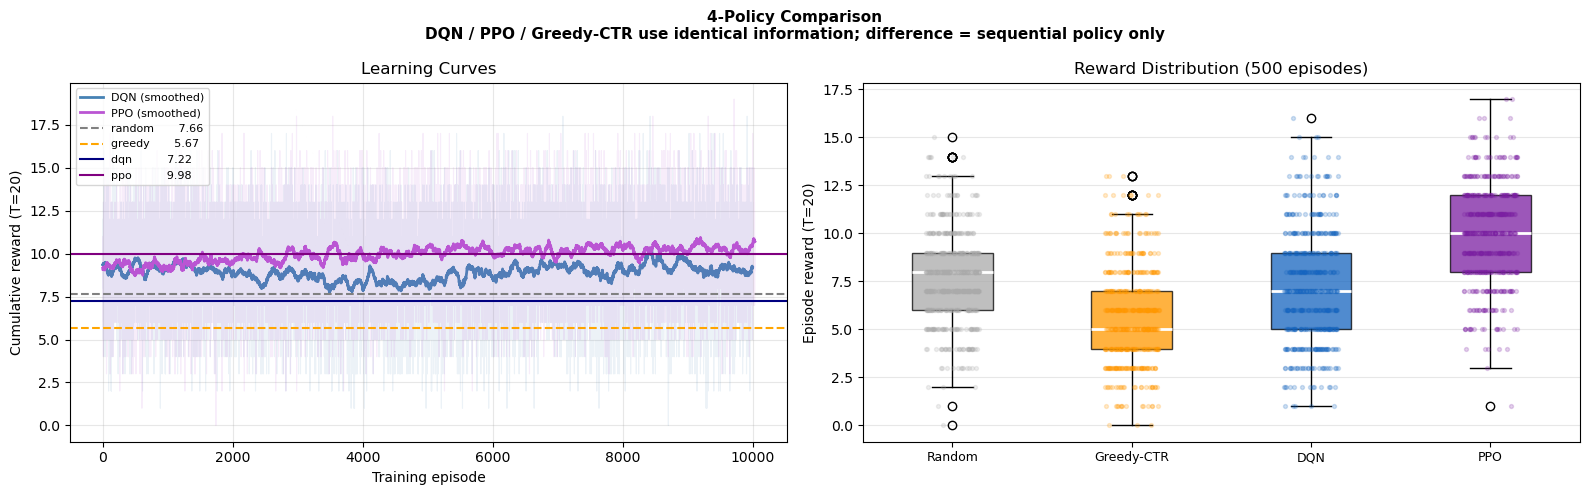

In [8]:
# CELL 8: Evaluate all policies
from evaluate import (
    run_full_evaluation, run_expected_evaluation,
    print_results_table, plot_comparison, run_ttest,
)

# Bernoulli reward evaluation
results = run_full_evaluation(env, model_dqn, model_ppo, n_eval=500, seed=42)
print_results_table(results, label="BERNOULLI REWARD")

# Expected reward evaluation (no sampling noise)
results_exp = run_expected_evaluation(env, model_dqn, model_ppo, n_eval=200)
print_results_table(results_exp, label="EXPECTED REWARD")

# Statistical significance
run_ttest(results, "dqn", "greedy")
run_ttest(results, "ppo", "greedy")

# Plots
plot_comparison(
    results,
    callback_dqn=callback_dqn,
    callback_ppo=callback_ppo,
    T=env.T,
    save_path="eda/09_policy_comparison.png",
)

Genre               DQN   DQN%       PPO   PPO%
--------------------------------------------------
Action                0  0.0%        74  0.7%
Adventure             0  0.0%        70  0.7%
Animation           361  3.6%       160  1.6%
Children's         4602 46.0%       179  1.8%
Comedy                0  0.0%       362  3.6%
Crime                 0  0.0%       192  1.9%
Documentary          30  0.3%      3100 31.0%
Drama                21  0.2%       107  1.1%
Fantasy               2  0.0%        24  0.2%
Film-Noir           826  8.3%      2704 27.0%
Horror               29  0.3%        12  0.1%
Musical             491  4.9%       563  5.6%
Mystery               0  0.0%        83  0.8%
Romance               6  0.1%        94  0.9%
Sci-Fi                0  0.0%         0  0.0%
Thriller            939  9.4%        90  0.9%
War                2559 25.6%      1973 19.7%
Western             134  1.3%       213  2.1%


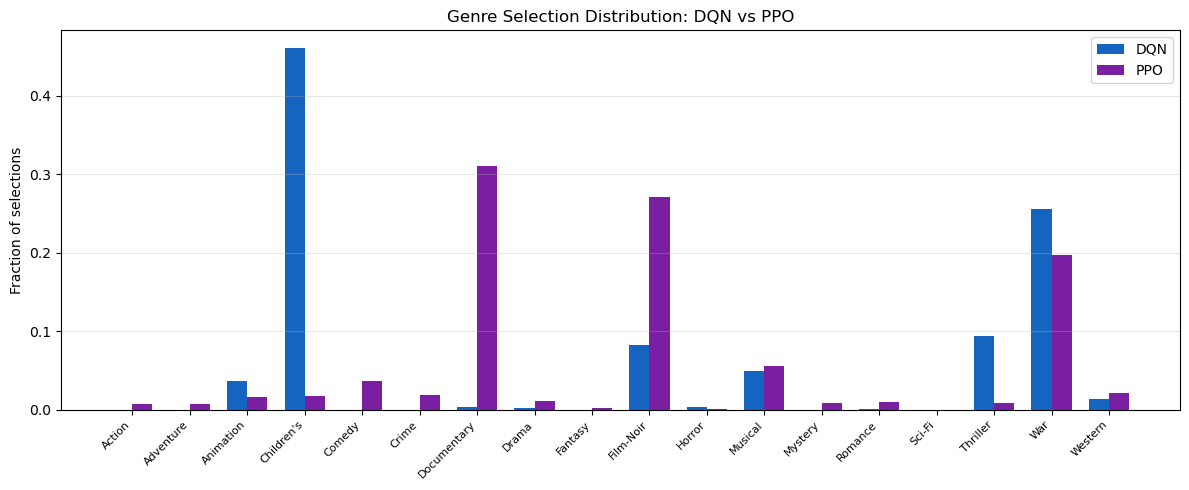

In [9]:
# CELL 9: Genre distribution analysis (DQN vs PPO)
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
 
def count_genre_selections(env, model, eval_users):
    counts = Counter()
    for user in eval_users:
        obs, _ = env.reset(options={"user_id": user})
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            counts[env.all_genres[int(action)]] += 1
            obs, _, done, _, _ = env.step(action)
    return counts
 
genre_counts_dqn = count_genre_selections(env, model_dqn, results["eval_users"])
genre_counts_ppo = count_genre_selections(env, model_ppo, results["eval_users"])
 
# Print side by side
total_dqn = sum(genre_counts_dqn.values())
total_ppo = sum(genre_counts_ppo.values())
 
print(f"{'Genre':<15s} {'DQN':>7s} {'DQN%':>6s}   {'PPO':>7s} {'PPO%':>6s}")
print("-" * 50)
for g in env.all_genres:
    d = genre_counts_dqn.get(g, 0)
    p = genre_counts_ppo.get(g, 0)
    print(f"{g:<15s} {d:7d} {d/total_dqn:5.1%}   {p:7d} {p/total_ppo:5.1%}")
 
# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(env.all_genres))
w = 0.35
 
dqn_vals = [genre_counts_dqn.get(g, 0) / total_dqn for g in env.all_genres]
ppo_vals = [genre_counts_ppo.get(g, 0) / total_ppo for g in env.all_genres]
 
ax.bar(x - w/2, dqn_vals, w, label="DQN", color="#1565c0")
ax.bar(x + w/2, ppo_vals, w, label="PPO", color="#7b1fa2")
ax.set_xticks(x)
ax.set_xticklabels(env.all_genres, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Fraction of selections")
ax.set_title("Genre Selection Distribution: DQN vs PPO")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
 
plt.tight_layout()
plt.savefig("eda/10_genre_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# CELL 10: Ablation study (state without genre counts)
from env import EnvNoGenreCounts
from evaluate import run_ablation_eval
 
env_ablation = EnvNoGenreCounts(ctx, gru4rec_p_like=gru4rec_p_like, T=20, window=10)
print(f"Ablation env — state shape: {env_ablation.observation_space.shape}")
 
# Train ablation DQN
callback_dqn_abl = EpisodeRewardCallback()
model_dqn_ablation = DQN(
    policy="MlpPolicy", env=env_ablation,
    policy_kwargs=dict(net_arch=[128, 128]),
    learning_rate=3e-4, gamma=0.99,
    buffer_size=30_000, learning_starts=1000,
    batch_size=128, exploration_fraction=0.5,
    exploration_final_eps=0.05, train_freq=4,
    target_update_interval=500, verbose=0, device="cpu",
)
print("Training DQN ablation (200k timesteps) ...")
model_dqn_ablation.learn(total_timesteps=200_000, callback=callback_dqn_abl,
                          progress_bar=True)
 
# Train ablation PPO
callback_ppo_abl = EpisodeRewardCallback()
model_ppo_ablation = PPO(
    policy="MlpPolicy", env=env_ablation,
    policy_kwargs=dict(net_arch=[128, 128]),
    learning_rate=3e-4, gamma=0.99,
    n_steps=2048, batch_size=128, n_epochs=10,
    verbose=0, device="cpu",
)
print("Training PPO ablation (200k timesteps) ...")
model_ppo_ablation.learn(total_timesteps=200_000, callback=callback_ppo_abl,
                          progress_bar=True)
 
# Evaluate ablation models on same users
eval_users = results["eval_users"]
dqn_abl_rewards = run_ablation_eval(env_ablation, model_dqn_ablation, eval_users, "DQN")
ppo_abl_rewards = run_ablation_eval(env_ablation, model_ppo_ablation, eval_users, "PPO")
 
print(f"\nDQN (full state): {np.mean(results['dqn']):.2f} ± {np.std(results['dqn']):.2f}")
print(f"DQN (no genre) : {np.mean(dqn_abl_rewards):.2f} ± {np.std(dqn_abl_rewards):.2f}")
print(f"PPO (full state): {np.mean(results['ppo']):.2f} ± {np.std(results['ppo']):.2f}")
print(f"PPO (no genre) : {np.mean(ppo_abl_rewards):.2f} ± {np.std(ppo_abl_rewards):.2f}")

Output()

Ablation env — state shape: (50,)
Training DQN ablation (200k timesteps) ...


Output()

Training PPO ablation (200k timesteps) ...


[ablation] DQN (no genre counts): 5.17 ± 2.32
[ablation] PPO (no genre counts): 5.55 ± 2.62

DQN (full state): 7.22 ± 2.95
DQN (no genre) : 5.17 ± 2.32
PPO (full state): 9.98 ± 2.54
PPO (no genre) : 5.55 ± 2.62


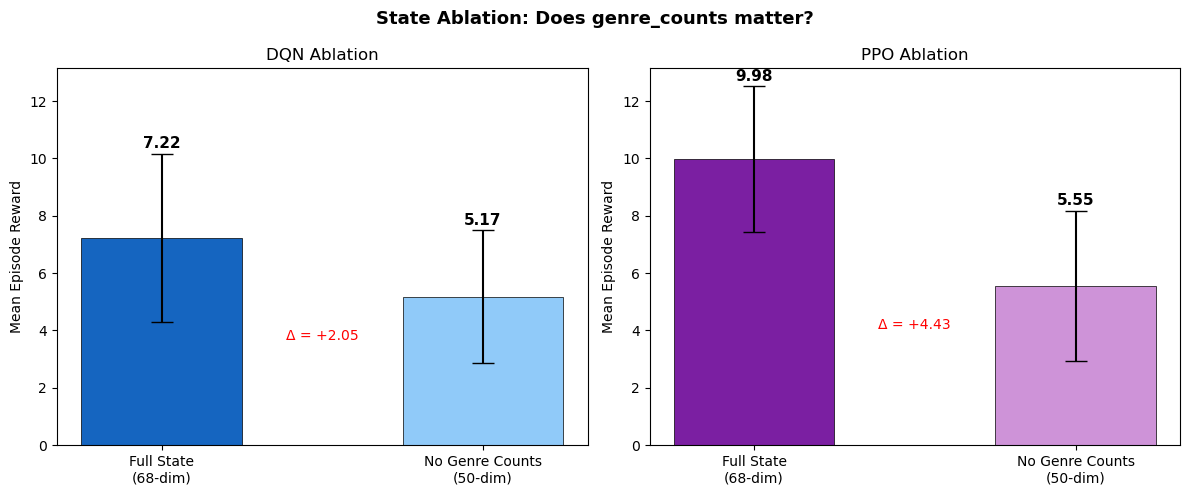

DQN drop: +2.05  (genre counts help)
PPO drop: +4.43  (genre counts help)


In [12]:
# CELL 11: Ablation comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
labels = ["Full State\n(68-dim)", "No Genre Counts\n(50-dim)"]
 
# DQN ablation
dqn_means = [np.mean(results["dqn"]), np.mean(dqn_abl_rewards)]
dqn_stds = [np.std(results["dqn"]), np.std(dqn_abl_rewards)]
 
axes[0].bar(labels, dqn_means, yerr=dqn_stds, capsize=8,
            color=["#1565c0", "#90caf9"], width=0.5, edgecolor="black", lw=0.5)
axes[0].set_ylabel("Mean Episode Reward")
axes[0].set_title("DQN Ablation")
for i, (m, s) in enumerate(zip(dqn_means, dqn_stds)):
    axes[0].text(i, m + s + 0.2, f"{m:.2f}", ha="center", fontsize=11, fontweight="bold")
drop_dqn = dqn_means[0] - dqn_means[1]
axes[0].text(0.5, min(dqn_means) - 1.5, f"Δ = {drop_dqn:+.2f}",
             ha="center", fontsize=10, color="red", transform=axes[0].transData)
 
# PPO ablation
ppo_means = [np.mean(results["ppo"]), np.mean(ppo_abl_rewards)]
ppo_stds = [np.std(results["ppo"]), np.std(ppo_abl_rewards)]
 
axes[1].bar(labels, ppo_means, yerr=ppo_stds, capsize=8,
            color=["#7b1fa2", "#ce93d8"], width=0.5, edgecolor="black", lw=0.5)
axes[1].set_ylabel("Mean Episode Reward")
axes[1].set_title("PPO Ablation")
for i, (m, s) in enumerate(zip(ppo_means, ppo_stds)):
    axes[1].text(i, m + s + 0.2, f"{m:.2f}", ha="center", fontsize=11, fontweight="bold")
drop_ppo = ppo_means[0] - ppo_means[1]
axes[1].text(0.5, min(ppo_means) - 1.5, f"Δ = {drop_ppo:+.2f}",
             ha="center", fontsize=10, color="red", transform=axes[1].transData)
 
# Match y-axis
y_max = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, y_max)
axes[1].set_ylim(0, y_max)
 
plt.suptitle("State Ablation: Does genre_counts matter?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda/11_ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"DQN drop: {drop_dqn:+.2f}  (genre counts {'help' if drop_dqn > 0 else 'hurt'})")
print(f"PPO drop: {drop_ppo:+.2f}  (genre counts {'help' if drop_ppo > 0 else 'hurt'})")

In [13]:
# CELL 12: GRU4Rec fatigue evaluation 
from gru4rec import probe_fatigue_curve, paired_fatigue_probe
 
print("Probing GRU4Rec fatigue signal ...")
fatigue_df = probe_fatigue_curve(env, ctx, n_users=30, n_targets_per_user=5, hist_len=4)
 
fatigue_summary = (
    fatigue_df.groupby("k_same_genre")["p_like"]
    .agg(["mean", "std"])
    .reset_index()
)
print("\nFatigue curve (P(like) by same-genre repetitions):")
print(fatigue_summary.to_string(index=False))
 
print("\nPaired fatigue probe ...")
paired_df = paired_fatigue_probe(env, ctx, n_pairs=200, hist_len=4)
print(f"Mean delta (mixed - same): {paired_df['delta_mix_minus_same'].mean():.4f}")
print(paired_df["delta_mix_minus_same"].describe())

Probing GRU4Rec fatigue signal ...

Fatigue curve (P(like) by same-genre repetitions):
 k_same_genre     mean      std
            0 0.434519 0.166821
            1 0.390729 0.173321
            2 0.332526 0.157680
            3 0.267376 0.147304
            4 0.206388 0.123965

Paired fatigue probe ...
Mean delta (mixed - same): 0.2308
count    200.000000
mean       0.230845
std        0.106519
min       -0.054847
25%        0.150305
50%        0.237824
75%        0.312084
max        0.491662
Name: delta_mix_minus_same, dtype: float64


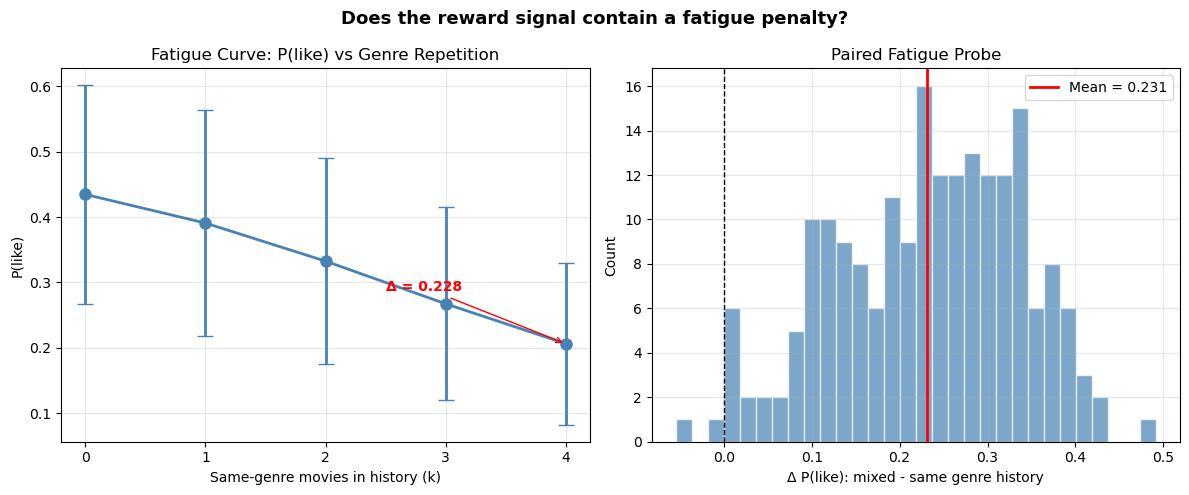

Fatigue drop (k=0 → k=4): 0.228
Paired delta mean: 0.231
Paired delta > 0: 97.5% of pairs


In [14]:
# CELL 13: Fatigue analysis plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Left: Fatigue curve
axes[0].errorbar(fatigue_summary["k_same_genre"], fatigue_summary["mean"],
                 yerr=fatigue_summary["std"], marker="o", capsize=6,
                 color="steelblue", lw=2, markersize=8)
axes[0].set_xlabel("Same-genre movies in history (k)")
axes[0].set_ylabel("P(like)")
axes[0].set_title("Fatigue Curve: P(like) vs Genre Repetition")
axes[0].set_xticks(range(5))
axes[0].grid(True, alpha=0.3)
 
drop = fatigue_summary["mean"].iloc[0] - fatigue_summary["mean"].iloc[-1]
axes[0].annotate(f"Δ = {drop:.3f}",
                 xy=(4, fatigue_summary["mean"].iloc[-1]),
                 xytext=(2.5, fatigue_summary["mean"].iloc[-1] + 0.08),
                 fontsize=10, color="red", fontweight="bold",
                 arrowprops=dict(arrowstyle="->", color="red"))
 
# Right: Paired probe distribution
axes[1].hist(paired_df["delta_mix_minus_same"], bins=30,
             color="steelblue", edgecolor="white", alpha=0.7)
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].axvline(paired_df["delta_mix_minus_same"].mean(), color="red", ls="-", lw=2,
                label=f"Mean = {paired_df['delta_mix_minus_same'].mean():.3f}")
axes[1].set_xlabel("Δ P(like): mixed - same genre history")
axes[1].set_ylabel("Count")
axes[1].set_title("Paired Fatigue Probe")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.suptitle("Does the reward signal contain a fatigue penalty?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda/12_fatigue_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"Fatigue drop (k=0 → k=4): {drop:.3f}")
print(f"Paired delta mean: {paired_df['delta_mix_minus_same'].mean():.3f}")
print(f"Paired delta > 0: {(paired_df['delta_mix_minus_same'] > 0).mean():.1%} of pairs")

In [15]:
# CELL 14: Save all artifacts
from evaluate import save_all_artifacts
 
save_all_artifacts(
    output_dir          = "outputs",
    model_dqn           = model_dqn,
    model_ppo           = model_ppo,
    gru4rec_model       = gru4rec_model,
    xgb_model           = xgb_model,
    U_embed             = U_embed,
    M_embed             = M_embed,
    model_dqn_ablation  = model_dqn_ablation,
    model_ppo_ablation  = model_ppo_ablation,
)

[save] All artifacts saved to 'outputs/':
outputs/
  embeddings/
    M_embed.npy                    0.71 MB
    U_embed.npy                    1.15 MB
  simulators/
    gru4rec_best.pt                1.02 MB
    xgb_simulator.json             0.92 MB
  agents/
    dqn_ablation_v8.zip            0.41 MB
    dqn_v8.zip                     0.45 MB
    ppo_ablation_v8.zip            0.59 MB
    ppo_v8.zip                     0.64 MB
